In [1]:
# Import important liabraries
import numpy as np
import pandas as pd
import matplotlib as mlt
import seaborn as sns
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")


In [2]:
gym = pd.read_csv("daily_gym_attendance_workout_data.csv") # import dataset
gym.head()

,member_id,visit_date,age,gender,membership_type,workout_type,workout_duration_minutes,calories_burned,check_in_time,attendance_status
0,1,2024-10-11,64,Other,Annual,HIIT,28,171,20:04,Absent
1,2,2024-06-01,65,Female,Quarterly,Strength Training,72,650,19:17,Absent
2,3,2024-06-13,45,Male,Quarterly,Cardio,70,633,7:24,Absent
3,4,2024-02-05,35,Female,Monthly,CrossFit,64,362,7:18,Absent
4,5,2024-07-13,26,Female,Quarterly,Yoga,31,262,11:22,Absent


In [3]:
# change in datatime format
gym['check_in_time'] = pd.to_datetime(gym['check_in_time'], format='%H:%M')

gym.dtypes   # check data types of all columns


member_id                            int64
visit_date                          object
age                                  int64
gender                              object
membership_type                     object
workout_type                        object
workout_duration_minutes             int64
calories_burned                      int64
check_in_time               datetime64[ns]
attendance_status                   object
dtype: object

In [4]:
gym.sum().isnull()    # find the null values of dataset

member_id                   False
visit_date                  False
age                         False
gender                      False
membership_type             False
workout_type                False
workout_duration_minutes    False
calories_burned             False
attendance_status           False
dtype: bool

In [5]:
gym.shape   # see the shape of dataset

(2600, 10)

In [6]:
# Drop multiple columns which is not required 
gym = gym.drop(['member_id', 'attendance_status', 'visit_date'], axis=1)


In [7]:
gym.head()

,age,gender,membership_type,workout_type,workout_duration_minutes,calories_burned,check_in_time
0,64,Other,Annual,HIIT,28,171,1900-01-01 20:04:00
1,65,Female,Quarterly,Strength Training,72,650,1900-01-01 19:17:00
2,45,Male,Quarterly,Cardio,70,633,1900-01-01 07:24:00
3,35,Female,Monthly,CrossFit,64,362,1900-01-01 07:18:00
4,26,Female,Quarterly,Yoga,31,262,1900-01-01 11:22:00


In [8]:
gym.nunique() # find unique values in dataset

age                          48
gender                        3
membership_type               3
workout_type                  5
workout_duration_minutes    101
calories_burned             880
check_in_time               982
dtype: int64

# Applying ML model

In [10]:
from sklearn.preprocessing import LabelEncoder

# List of categorical columns
categorical_cols = ['gender', 'membership_type', 'workout_type']

# Encode each categorical column for that use for loop in categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    gym[col] = le.fit_transform(gym[col])



In [11]:
gym.head()

,age,gender,membership_type,workout_type,workout_duration_minutes,calories_burned,check_in_time
0,64,2,0,2,28,171,1900-01-01 20:04:00
1,65,0,2,3,72,650,1900-01-01 19:17:00
2,45,1,2,0,70,633,1900-01-01 07:24:00
3,35,0,1,1,64,362,1900-01-01 07:18:00
4,26,0,2,4,31,262,1900-01-01 11:22:00


In [12]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report



In [13]:
# Extract useful time features
gym['hour'] = gym['check_in_time'].dt.hour
gym['minute'] = gym['check_in_time'].dt.minute
gym['weekday'] = gym['check_in_time'].dt.weekday


In [14]:
gym.head(3)

,age,gender,membership_type,workout_type,workout_duration_minutes,calories_burned,check_in_time,hour,minute,weekday
0,64,2,0,2,28,171,1900-01-01 20:04:00,20,4,0
1,65,0,2,3,72,650,1900-01-01 19:17:00,19,17,0
2,45,1,2,0,70,633,1900-01-01 07:24:00,7,24,0


In [17]:
df = gym.copy()

# Extract time features
df['hour'] = df['check_in_time'].dt.hour
df['minute'] = df['check_in_time'].dt.minute

# Drop weekday since it's meaningless here
# df['weekday'] = df['check_in_time'].dt.weekday   # remove this line

# Extract date parts
df['day'] = df['check_in_time'].dt.day
df['month'] = df['check_in_time'].dt.month
df['year'] = df['check_in_time'].dt.year

# Drop raw datetime if you don’t want it anymore
# (optional, keep if you want to engineer rolling features later)
df = df.drop(columns=['check_in_time'])

# One-hot encode categorical features
X = pd.get_dummies(df.drop('workout_type', axis=1), drop_first=True)
y = df['workout_type']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# Target: calories burned
y = df['calories_burned']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------- Random Forest Regressor ----------------
rf_reg = RandomForestRegressor(n_estimators=300, random_state=42)
rf_reg.fit(X_train, y_train)
rf_pred = rf_reg.predict(X_test)

print("Random Forest R²:", r2_score(y_test, rf_pred))
print("Random Forest RMSE:", mean_squared_error(y_test, rf_pred, squared=False))

# ---------------- XGBoost Regressor ----------------
xgb_reg = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42)
xgb_reg.fit(X_train, y_train)
xgb_pred = xgb_reg.predict(X_test)

print("XGBoost R²:", r2_score(y_test, xgb_pred))
print("XGBoost RMSE:", mean_squared_error(y_test, xgb_pred, squared=False))


Random Forest R²: 0.9999889637862212
Random Forest RMSE: 0.8119393792368718
XGBoost R²: 0.9999221375084472
XGBoost RMSE: 2.1566402258223416


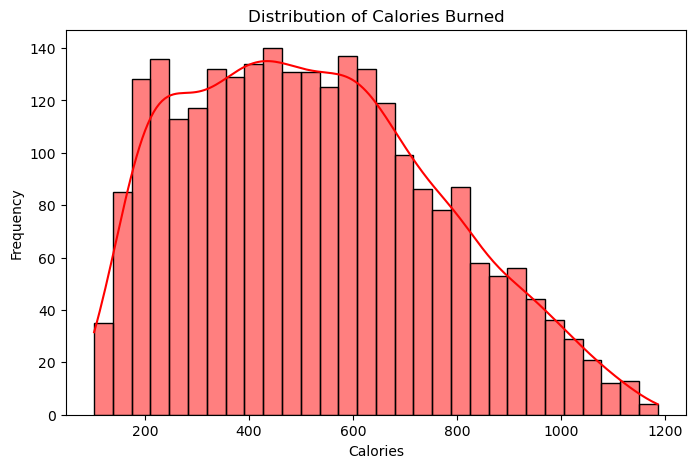

In [19]:

plt.figure(figsize=(8,5))
sns.histplot(df['calories_burned'], bins=30, kde=True, color='red')
plt.title("Distribution of Calories Burned")
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.show()


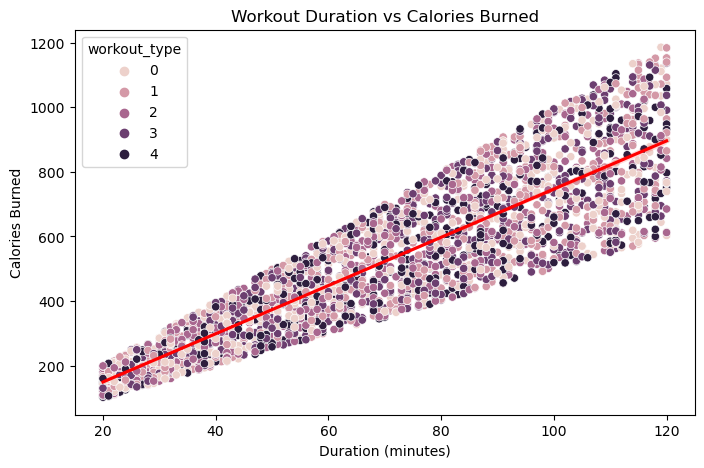

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='workout_duration_minutes', y='calories_burned', hue='workout_type', data=df)
sns.regplot(x='workout_duration_minutes', y='calories_burned', data=df, scatter=False, color='red')
plt.title("Workout Duration vs Calories Burned")
plt.xlabel("Duration (minutes)")
plt.ylabel("Calories Burned")
plt.show()


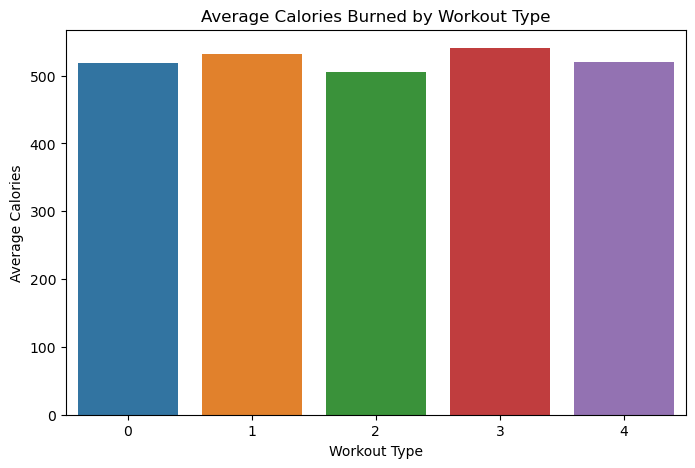

In [21]:
plt.figure(figsize=(8,5))
sns.barplot(x='workout_type', y='calories_burned', data=df, estimator='mean', ci=None)
plt.title("Average Calories Burned by Workout Type")
plt.xlabel("Workout Type")
plt.ylabel("Average Calories")
plt.show()
